In [1]:
def plot_with_best_fit_line(results_df, ax, col1, col2, label1, label2, title):
    x = results_df[col1]
    y = results_df[col2]

    ax.scatter(x, y)

    # 🔹 Fit line
    m, b = np.polyfit(x, y, 1)

    # Predicted values
    y_pred = m * x + b

    # R²
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - (ss_res / ss_tot)

    # 🔹 Create line values
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = m * x_line + b

    # 🔹 Plot line
    ax.plot(x_line, y_line, color='black')

    ax.text( 0.05, 0.95,  f'$R^2 = {r2:.2f}$', transform=ax.transAxes, verticalalignment='top')

    ax.set_xlabel(label1)
    ax.set_ylabel(label2)
    
    ax.set_title(title)


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pyproj import Transformer

In [3]:
CATCHMENT_NUMBER = 23

### Get data across all ensemble members

In [4]:
def filter_closer_to_catchment(cube, catchment_poly, plot=False, boundary_gdf = None):

    minx, miny, maxx, maxy = catchment_poly.bounds

    buffer = 2500  # metres

    constraint = iris.Constraint( projection_x_coordinate=lambda x: (minx - buffer) <= x <= (maxx + buffer),
        projection_y_coordinate=lambda y: (miny - buffer) <= y <= (maxy + buffer))

    sub_cube = cube.extract(constraint)
    
    if plot==True:
        fig, ax = plt.subplots(figsize=(6,6), subplot_kw={'projection': ccrs.OSGB()})
        qplt.pcolormesh(sub_cube[2], axes=ax, cmap = 'Blues', edgecolor='black', linewidth=0.5)
        boundary_gdf.boundary.plot(ax=ax, color='black');
        
    return sub_cube

### get hydraulic conductivity data

In [8]:
import geopandas as gpd
import iris

results_all = pd.read_csv(f"../../Data/EventDetails/Catchment_{CATCHMENT_NUMBER}/results_all_ensembles.csv")

hc = iris.load(f"/scratch/hydro4/users/kv25483/FutureFlood/Data/HydraulicConductivity/5km_{CATCHMENT_NUMBER}.nc")[0]

## Filter it to catchment, so can use indexing to find cell which had peak
MOLLY_DIR_FF = "/scratch/hydro4/users/kv25483/FutureFlood/"
catchments = gpd.read_file(MOLLY_DIR_FF + "Data/CatchmentShapefiles/hyd_areas_GB_with_subcatchments.shp")
boundary_gdf = catchments[catchments['HA_NUM'] == str(CATCHMENT_NUMBER)]
boundary_gdf.reset_index(inplace=True, drop=True)
CATCHMENT_POLY = boundary_gdf.geometry.iloc[0]
hc = filter_closer_to_catchment(hc, CATCHMENT_POLY)
hc[12, 1]
# hc_values = []

# for _, row in results_all.iterrows():
#     x_idx = int(row["x_idx"])
#     y_idx = int(row["y_idx"])

#     hc_values.append(hc[y_idx, x_idx].data.item())

# results_all["hydraulic_conductivity"] = hc_values

Hydraulic Conductivity (m/day),(scalar cube)
Scalar coordinates,
projection_x_coordinate,"357500.0 m, bound=(355000.0, 360000.0) m"
projection_y_coordinate,"592500.0 m, bound=(590000.0, 595000.0) m"
Attributes,
description,'Mean hydraulic conductivity aggregated from 30m to 5km'


In [9]:
results_all[["x_idx", "y_idx", "x_coord", "y_coord"]]

,x_idx,y_idx,x_coord,y_coord
0,1,12,357500.0,592500.0
1,9,12,397500.0,592500.0
2,5,5,377500.0,557500.0
3,11,3,407500.0,547500.0
4,15,7,427500.0,567500.0
...,...,...,...,...
857,12,7,412500.0,567500.0
858,3,1,367500.0,537500.0
859,7,8,387500.0,572500.0
860,8,9,392500.0,577500.0


In [69]:
results_all.to_csv(f"../../Data/EventDetails/Catchment_{CATCHMENT_NUMBER}/results_all_ensembles.csv")

In [55]:
explainer_variables = ['max_precip', 'x_coord', 'y_coord', 'total_acc','peak_position_ratio', 'd50', 'gini', 'time_based_std', 
                       'dry_ratio', 'max_quartile_index', '10cm_neighbourhood_sum', 'within_10km_city_centre',
#                        'mean_sm_2_before_event', 'mean_sm_3_before_event', 'mean_sm_4_before_event', 'mean_sm_5_before_event',
                       'mean_sm_catchment']
predictor_variable = '10cm_fld_area_at_peak'

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Split data into train/test
X_train, X_test, y_train, y_test = train_test_split(results_all[explainer_variables], 
                                                    results_all[predictor_variable], 
                                                    test_size=0.2, random_state=42)

# Fit Random Forest
rf = RandomForestRegressor(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Model performance
print("R²:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred))

R²: 0.8306050361871509
RMSE: 0.028815556751564525


x_coord                    0.448557
total_acc                  0.155984
y_coord                    0.117201
max_precip                 0.100906
10cm_neighbourhood_sum     0.046406
mean_sm_catchment          0.021521
gini                       0.021447
d50                        0.019780
peak_position_ratio        0.019404
within_10km_city_centre    0.018509
time_based_std             0.017608
dry_ratio                  0.010713
max_quartile_index         0.001963
dtype: float64


/tmp/ipykernel_1239540/1251516029.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette="viridis")


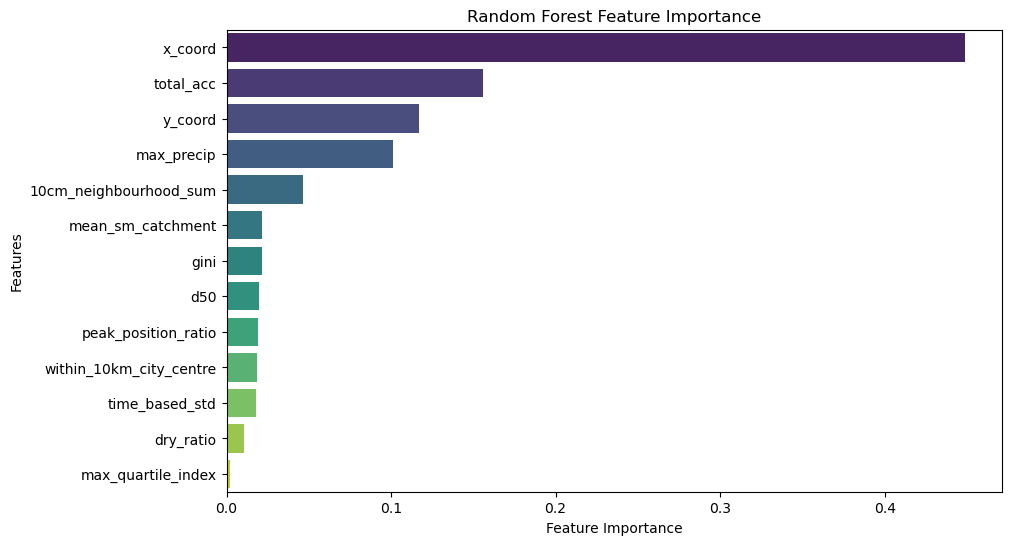

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'rf' is your trained RandomForestRegressor
feature_importances = pd.Series(rf.feature_importances_, index=explainer_variables)

# Sort descending
feature_importances = feature_importances.sort_values(ascending=False)

# Print
print(feature_importances)

# Optional: plot
plt.figure(figsize=(10,6))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette="viridis")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")
plt.show()

In [58]:
# near_newcastle = results_all[results_all["within_10km_city_centre"]==True]

near_newcastle = results_all[results_all["hydraulic_conductivity"]<0.5]

In [59]:
# from scipy.stats import linregress
# df = near_newcastle.copy()
# explainer_varible = 'mean_sm_2_before_event'
# x = df['total_acc']
# y = df['10cm_fld_area_at_peak']

# # Fit linear regression
# slope, intercept, r_value, p_value, std_err = linregress(x, y)

# # Predicted values
# y_pred = intercept + slope * x

# # Residuals
# df['residuals'] = y - y_pred

# import matplotlib.pyplot as plt

# plt.figure(figsize=(6, 4))
# plt.scatter(df[explainer_varible], df['residuals'])

# plt.axhline(0, linestyle='--')  # reference line
# plt.xlabel('Mean soil moisture')
# plt.ylabel('Residual flood area')
# plt.title('Residuals vs Soil Moisture')

# plt.show()

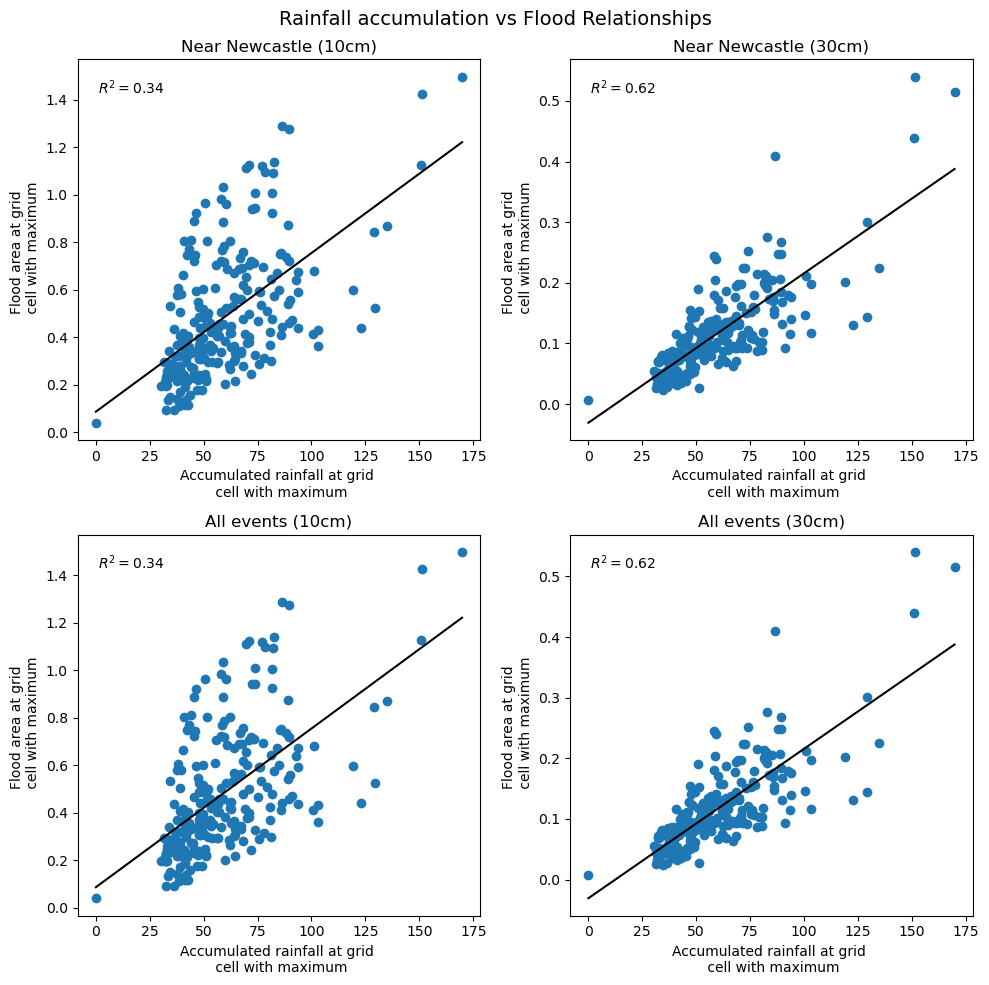

In [62]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10,10))

# --- Top row: Near Newcastle ---
plot_with_best_fit_line(
    near_newcastle, axs[0, 0],
    'total_acc', '10cm_thr0.3_fld_area_at_peak',
    'Accumulated rainfall at grid \n cell with maximum',
    'Flood area at grid \n cell with maximum',
    'Flooding over 10cm')

plot_with_best_fit_line(
    near_newcastle, axs[0, 1],
    'total_acc', '30cm_thr0.3_fld_area_at_peak',
    'Accumulated rainfall at grid \n cell with maximum',
    'Flood area at grid \n cell with maximum',
    'Flooding over 30cm')

# --- Bottom row: All events ---
plot_with_best_fit_line(
    results_all, axs[1, 0],
    'total_acc', '10cm_thr0.3_fld_area_at_peak',
    'Accumulated rainfall at grid \n cell with maximum',
    'Flood area at grid \n cell with maximum',
    'Flooding over 10cm')

plot_with_best_fit_line(
    results_all, axs[1, 1],
    'total_acc', '30cm_thr0.3_fld_area_at_peak',
    'Accumulated rainfall at grid \n cell with maximum',
    'Flood area at grid \n cell with maximum',
    'Flooding over 30cm')

# Titles for rows (optional but clearer)
axs[0, 0].set_title("Near Newcastle (10cm)")
axs[0, 1].set_title("Near Newcastle (30cm)")
axs[1, 0].set_title("All events (10cm)")
axs[1, 1].set_title("All events (30cm)")

fig.suptitle("Rainfall accumulation vs Flood Relationships", fontsize=14)
fig.tight_layout()

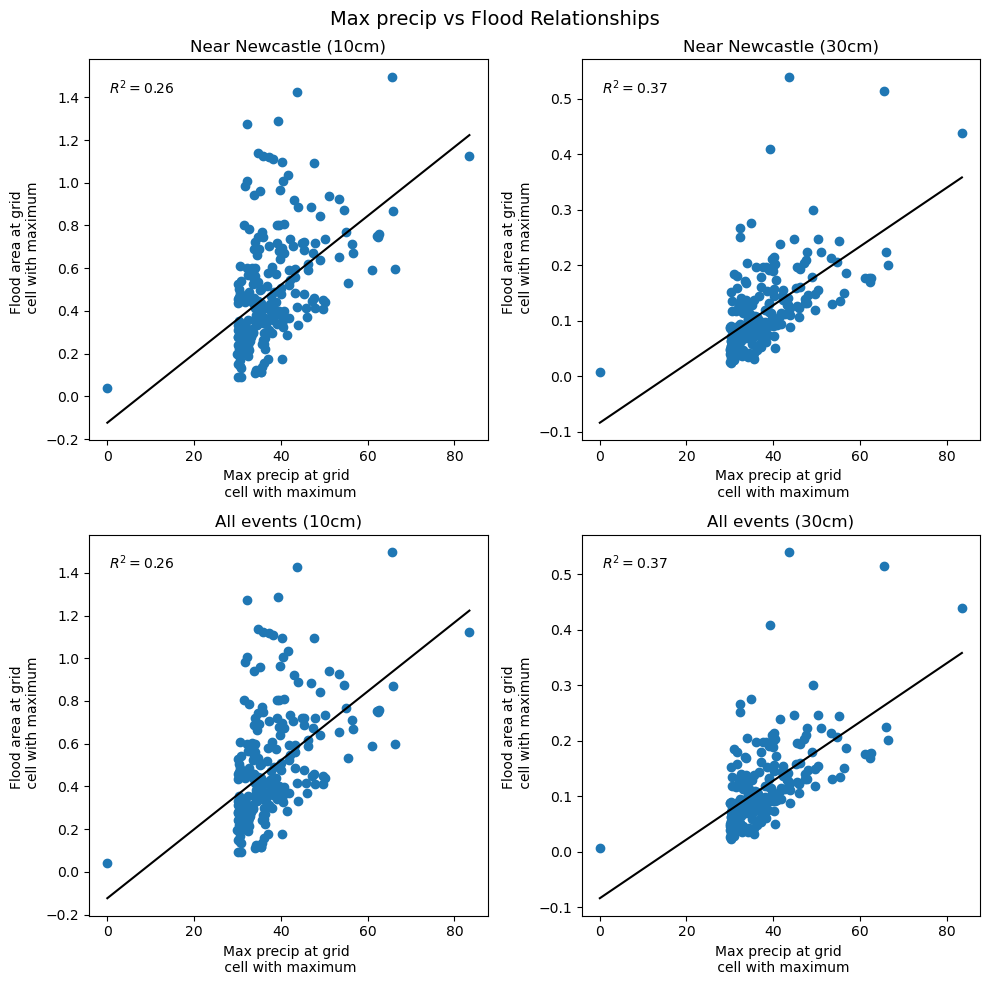

In [63]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10,10))

# --- Top row: Near Newcastle ---
plot_with_best_fit_line(
    near_newcastle, axs[0, 0],
    'max_precip', '10cm_thr0.3_fld_area_at_peak',
    'Max precip at grid \n cell with maximum',
    'Flood area at grid \n cell with maximum',
    'Flooding over 10cm')

plot_with_best_fit_line(
    near_newcastle, axs[0, 1],
    'max_precip', '30cm_thr0.3_fld_area_at_peak',
    'Max precip at grid \n cell with maximum',
    'Flood area at grid \n cell with maximum',
    'Flooding over 30cm')

# --- Bottom row: All events ---
plot_with_best_fit_line(
    results_all, axs[1, 0],
    'max_precip', '10cm_thr0.3_fld_area_at_peak',
    'Max precip at grid \n cell with maximum',
    'Flood area at grid \n cell with maximum',
    'Flooding over 10cm')

plot_with_best_fit_line(
    results_all, axs[1, 1],
    'max_precip', '30cm_thr0.3_fld_area_at_peak',
    'Max precip at grid \n cell with maximum',
    'Flood area at grid \n cell with maximum',
    'Flooding over 30cm')

# Titles for rows (optional but clearer)
axs[0, 0].set_title("Near Newcastle (10cm)")
axs[0, 1].set_title("Near Newcastle (30cm)")
axs[1, 0].set_title("All events (10cm)")
axs[1, 1].set_title("All events (30cm)")

fig.suptitle("Max precip vs Flood Relationships", fontsize=14)
fig.tight_layout()

In [13]:
# fig, axs = plt.subplots(ncols=2, figsize=(10,3))
# plot_with_best_fit_line(near_newcastle, axs[0], 'max_precip', '10cm_fld_area_under_cluster',
#                        'Maximum precipitation intensity', 'Flood area at grid \n cell with maximum',
#                        'Flooding over 10cm')
# plot_with_best_fit_line(near_newcastle, axs[1], 'max_precip', '30cm_fld_area_under_cluster',
#                        'Maximum precipitation intensity', 'Flood area at grid \n cell with maximum',
#                        'Flooding over 30cm')
# # fig.tight_layout()